# The Mersenne Number Public-Key Cryptosystem [AJPS18]

**Cryptography and Security Protocols &ndash; Project 27**

*Hugo Palhares*

## 1. Motivation

Classical public-key cryptography (RSA, elliptic curves) relies on integer factorisation and discrete logarithms, both broken by a large-scale quantum computer with Shor's algorithm, which drives the search for post-quantum schemes.

In 2018, Aggarwal, Joux, Prakash and Santha proposed a new system whose key characteristic is that, instead of polynomial rings, it uses ordinary integer arithmetic modulo a Mersenne prime. The only objects are integers with very few $1$-bits, and the only operations are modular addition and multiplication.

A Mersenne prime is a prime of the form $p = 2^n - 1, n \text{ prime}.$ Using a known Mersenne-prime exponent guarantees $p$ is prime, so every nonzero element is invertible modulo $p$.

In [19]:
import secrets
import random
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [20]:
mersenne_exponents = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127,
    521, 607, 1279, 2203, 2281, 3217, 4253, 4423,
    9689, 9941, 11213, 19937, 86243, 132049, 216091
]

def mersenne_prime(n: int) -> int:
    if n not in mersenne_exponents:
        raise ValueError(f"2**{n}-1 is not a known Mersenne prime")
    return (2**n) - 1

print("Example:  n = 13,  p = 2^13 - 1 =", mersenne_prime(13))
print("Binary notation of p: ", bin(mersenne_prime(13)))

Example:  n = 13,  p = 2^13 - 1 = 8191
Binary notation of p:  0b1111111111111


## 2. Hamming weight

Every residue in $\mathbb{Z}_p$ is an $n$-bit string. The Hamming weight of a number is simply its count of $1$-bits. A number is low weight (parameter $h$) if it has a low number of 1's in its binary notation. These low-weight numbers are the central object of the whole scheme.

In [21]:
def hamming_weight(x: int) -> int:
    return bin(x).count("1")

def sample_low_weight(n, h, rng=None):
    if rng is None:
        pos = set()
        while len(pos) < h:
            pos.add(secrets.randbelow(n))
    else:
        pos = set(rng.sample(range(n), h))
    x = 0
    for p in pos:
        x |= (2**p)
    return x

n_2 = 16
h_2 = 5
x = sample_low_weight(n_2, h_2, random.Random(1))
print(f"a weight-{h_2} number on {n_2} bits:  {x:016b}   (weight = {hamming_weight(x)})")

a weight-5 number on 16 bits:  0011001000010010   (weight = 5)


## 3. Useful properties

$2^n \equiv 1$ mod $2^n - 1$, so multiplying by $2$ shifts every bit left and
wraps the top bit around to the bottom, so a rotation never changes the number of $1$-bits.

$$\textbf{Lemma (rotation):}\quad \mathrm{Ham}(2^k x \bmod p) = \mathrm{Ham}(x).$$

From the rotation property, three more facts follow (these are everything the scheme needs):

$$
\begin{aligned}
\textbf{addition:} &\quad \mathrm{Ham}(a+b \bmod p) \le \mathrm{Ham}(a)+\mathrm{Ham}(b)\\[2pt]
\textbf{multiplication:} &\quad \mathrm{Ham}(a\cdot b \bmod p) \le \mathrm{Ham}(a)\cdot\mathrm{Ham}(b)\\[2pt]
\textbf{negation:} &\quad \mathrm{Ham}(-a \bmod p) = n - \mathrm{Ham}(a)
\end{aligned}
$$

## 4. AJPS-1

Fix $p = 2^n-1$ and a small weight $h$ with $4h^2 < n$. Every sampled value is a random
$n$-bit number of weight $h$.

**Key generation:** Pick secret low-weight $F, G$ and publish
$$ H = F \cdot G^{-1} \bmod p \qquad(\text{private key} = G, \text{public key} = H).$$

**Encrypt a bit:** $b \in \{0,1\}$ with fresh low-weight $A, B$:
$$ C = (-1)^b\,(A\cdot H + B) \bmod p.$$

**Decryption:** Compute $d = C\cdot G \bmod p$; output $0$ if $\mathrm{Ham}(d)$ is small,
$1$ if it is large.

### Practical example

| Party | Generates | **Publishes** | **Keeps secret** | **Sends** |
|-------|-----------|---------------|------------------|-----------|
| **Alice** (receiver) | $F, G, H$ | $H$, n, h | $G$, $F$ (discarded) | x |
| **Bob** (sender) | $A, B$ (temporary) | x | $A, B$ (both discarded) | ciphertext $C$ |

An eavesdropper sees only $H$ and $C$ (and the parameters $p, n, h$). Breaking the scheme
means either factoring $H$ back into its low-weight parts $F/G$, or decomposing $C$ without
$G$, both assumed hard.

In [22]:
class AJPS:
    def __init__(self, n, h, rng=None):
        self.n, self.h, self.p, self.rng = n, h, mersenne_prime(n), rng

    def keygen(self):
        F = sample_low_weight(self.n, self.h, self.rng)
        G = sample_low_weight(self.n, self.h, self.rng)
        H = (F * pow(G, -1, self.p)) % self.p
        return H, G

    def encrypt(self, H, bit):
        A = sample_low_weight(self.n, self.h, self.rng)
        B = sample_low_weight(self.n, self.h, self.rng)
        C = (A * H + B) % self.p
        return (-C) % self.p if bit == 1 else C

    def decrypt(self, G, C):
        d = (C * G) % self.p
        return 0 if hamming_weight(d) < (self.n / 2) else 1

    def encrypt_message(self, H, data: bytes):
        bits = [(byte // 2**i) % 2 for byte in data for i in range(7, -1, -1)]
        return [self.encrypt(H, b) for b in bits]

    def decrypt_message(self, G, cts):
        bits = [self.decrypt(G, c) for c in cts]
        out = bytearray()
        for i in range(0, len(bits), 8):
            byte = 0
            for b in bits[i:i+8]:
                byte = (byte << 1) | b
            out.append(byte)
        return bytes(out)

## 5. Demo with small numbers

We will use the parameters $n=1279$, $h=8$ (so $4h^2 = 256 < 1279$). (these are not secure, just used to make the demo fast)

In [23]:
cipher = AJPS(n=1279, h=8)
H, G = cipher.keygen()

print(f"Public key  H = {str(H)[:46]}...")
print(f"Ham(H) = {hamming_weight(H)},   Ham(G) = {hamming_weight(G)},   Ham(G^-1) = {hamming_weight(pow(G, -1, cipher.p))}\n")

secret_bit = 1
C = cipher.encrypt(H, secret_bit)
print(f"Bob encrypts bit b = {secret_bit}")
print(f"Ciphertext  C = {str(C)[:46]}... weight = {hamming_weight(C)}\n")

d = (C * G) % cipher.p
print(f"Alice computes Ham(C*G mod p) = {hamming_weight(d)}   (threshold n/2 = {cipher.n // 2})")
print(f"Recovered bit = {cipher.decrypt(G, C)}")

Public key  H = 3051376593631319629507150833355010822757783402...
Ham(H) = 639,   Ham(G) = 8,   Ham(G^-1) = 615

Bob encrypts bit b = 1
Ciphertext  C = 1273530381623413095665140341307349685501565984... weight = 617

Alice computes Ham(C*G mod p) = 1161   (threshold n/2 = 639)
Recovered bit = 1


## 6. Decryption

Multiplying by the secret $G$ cancels the $G^{-1}$ hidden inside $H$:
$$ C\cdot G = (-1)^b (A\cdot H + B)\cdot G = (-1)^b\,(A\cdot F + B\cdot G) \pmod p.$$
By the multiplication and addition lemmas, $\mathrm{Ham}(A\cdot F + B\cdot G) \le 2h^2$.

- If $b=0$: $\mathrm{Ham}(d) \le 2h^2$
- If $b=1$: $d$ is the negation, so $\mathrm{Ham}(d) \ge n - 2h^2$

**Theorem.** If $4h^2 < n$, the two ranges cannot overlap, so thresholding at $n/2$ always
recovers $b$.

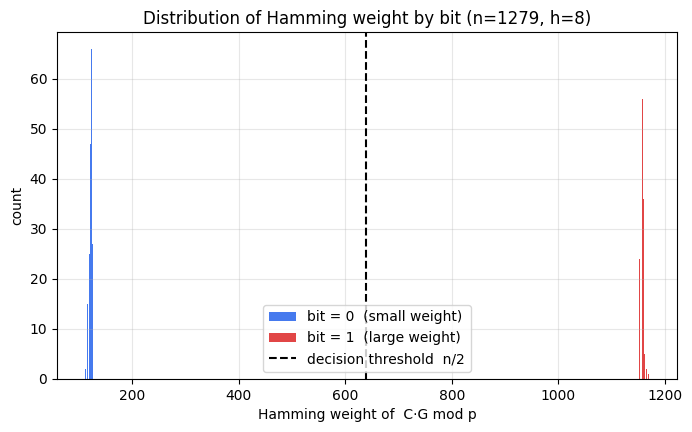

bit 0: weights in [111, 128]   (bound 2h^2 = 128)
bit 1: weights in [1152, 1170]   (n - 2h^2 = 1151)


In [24]:
demo = AJPS(n=1279, h=8, rng=random.Random(0))
H, G = demo.keygen()
N = 400
w0 = [hamming_weight((demo.encrypt(H, 0) * G) % demo.p) for _ in range(N)]
w1 = [hamming_weight((demo.encrypt(H, 1) * G) % demo.p) for _ in range(N)]

plt.hist(w0, bins=30, alpha=0.85, color="#2563eb", label="bit = 0  (small weight)")
plt.hist(w1, bins=30, alpha=0.85, color="#dc2626", label="bit = 1  (large weight)")
plt.axvline(demo.n / 2, color="black", linestyle="--", label="decision threshold  n/2")
plt.xlabel("Hamming weight of  C·G mod p")
plt.ylabel("count")
plt.title(f"Distribution of Hamming weight by bit (n={demo.n}, h={demo.h})")
plt.legend()
plt.show()

print(f"bit 0: weights in [{min(w0)}, {max(w0)}]   (bound 2h^2 = {2*demo.h**2})")
print(f"bit 1: weights in [{min(w1)}, {max(w1)}]   (n - 2h^2 = {demo.n - 2*demo.h**2})")

## 7. Correctness boundary

Now let's test this correctness boundary by sweeping $h$ and plotting the error rate for two values of $n$.

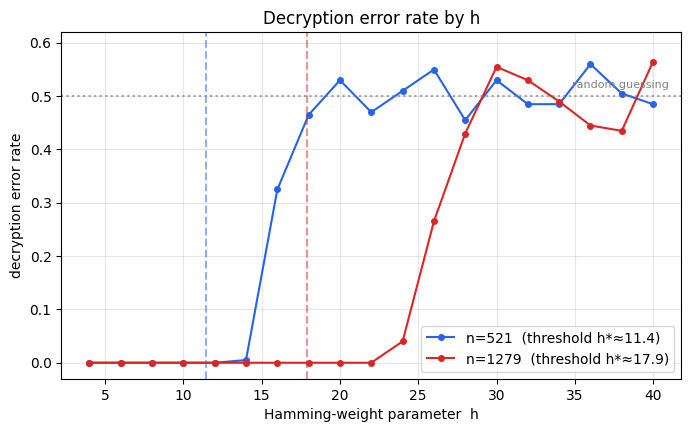

In [25]:
def error_rate(n, h, trials=200, seed=0):
    c = AJPS(n, h, rng=random.Random(seed + h))
    H, G = c.keygen()
    mr = random.Random(seed + h + 7)
    err = sum(c.decrypt(G, c.encrypt(H, (b := mr.randint(0, 1)))) != b for _ in range(trials))
    return err / trials

hs = list(range(4, 42, 2))
for n, color in [(521, "#2563eb"), (1279, "#dc2626")]:
    rates = [error_rate(n, h) for h in hs]
    h_star = (n ** 0.5) / 2
    plt.plot(hs, rates, "o-", color=color, ms=4, label=f"n={n}  (threshold h*≈{h_star:.1f})")
    plt.axvline(h_star, color=color, linestyle="--", alpha=0.5)

plt.axhline(0.5, color="gray", linestyle=":", alpha=0.7)
plt.text(41, 0.515, "random guessing", ha="right", fontsize=8, color="gray")
plt.xlabel("Hamming-weight parameter  h")
plt.ylabel("decryption error rate")
plt.title("Decryption error rate by h")
plt.ylim(-0.03, 0.62)
plt.legend()
plt.show()

## 8. Ciphertext size

Each bit becomes one $\sim\!n$-bit ciphertext, blowing up the size of the message.

In [26]:
msg = "Crypto!"
c = AJPS(n=1279, h=8, rng=random.Random(7))
H, G = c.keygen()
cts = c.encrypt_message(H, msg.encode())
recovered = c.decrypt_message(G, cts).decode()
total_bits = len(cts) * c.n

print(f"message    : {msg!r}   ({len(msg)} bytes = {len(msg)*8} bits)")
print(f"ciphertext : {len(cts)} numbers x ~{c.n} bits = {total_bits:,} bits  (~{total_bits//8//1024} KB)")
print(f"expansion  : about {total_bits // (len(msg)*8):,}x larger than the plaintext")
print(f"recovered  : {recovered!r}   ->  match: {recovered == msg}")

message    : 'Crypto!'   (7 bytes = 56 bits)
ciphertext : 56 numbers x ~1279 bits = 71,624 bits  (~8 KB)
expansion  : about 1,279x larger than the plaintext
recovered  : 'Crypto!'   ->  match: True


This blow-up is exactly why the paper also defines a **blockwise** scheme, which I will show later.

## 9. Security

The scheme rests on two conjectured-hard problems over $p = 2^n-1$ with weight $h$:

- Given $H = F/G \bmod p$, recovering F and G
- Given $(R,\,A\cdot R + B)$, distinguishing it from a uniformly random pair.

### The brute-force baseline
There are $\binom{n}{h}\approx (n/h)^h$ binary strings of weight $h$, from which the authors argued that searching this exponential space was essentially optimal, and so set $h = \lambda$ for $\lambda$-bit security. However, it was later discovered that this estimate was too optimistic and there was one structural attack that could do far better.

### Lattice - Beunardeau et al.
The goal is to recover $F,G$ from $H = F/G \bmod p$.

- A random weight-$h$ number usually has its $1$-bits spread across all $n$ positions, so typically $F,G \approx p$ in size. But with probability $\approx 2^{-2h}$, all set bits of both land in the low half of the positions, making $F, G < \sqrt{p}$.
- When that happens, $(F,G)$ is an unusually short vector in the 2-D lattice
$L = \{(x,y) : x \equiv H\!\cdot\! y \ (\mathrm{mod}\ p)\}$ (generated by $(p,0)$ and $(H,1)$), and LLL in dimension $2$ recovers it exactly.
- To force a weak instance, multiply $H$ by random powers of $2$ (this just     rotates $F,G$) and retry $\approx 2^{2h}$ times. A refined partition version relaxes "low half" to "near window boundaries," improving the constant.

Net cost $\mathcal{O}(2^{2h})$ which only gives us about $2h$ bits of security. The originally recommended $h = 17$ gives $\approx 34$ bits of security, which is essentially breakable with a common laptop.

### Consequence for parameters
To survive the lattice attack at level $\lambda$ we need $2h \gtrsim \lambda$, i.e.
$h \gtrsim \lambda/2$ (AJPS conservatively take $h=\lambda$). The correctness condition then forces
$$ n > 4h^2 \approx 4\lambda^2 . $$
For $\lambda = 128$ this means $n \gtrsim 6.5\times10^4$, with the admissible band
$4h^2 < n \le 16h^2$. Real instantiations therefore use large Mersenne exponents which lead to a bigger increase in ciphertext size.

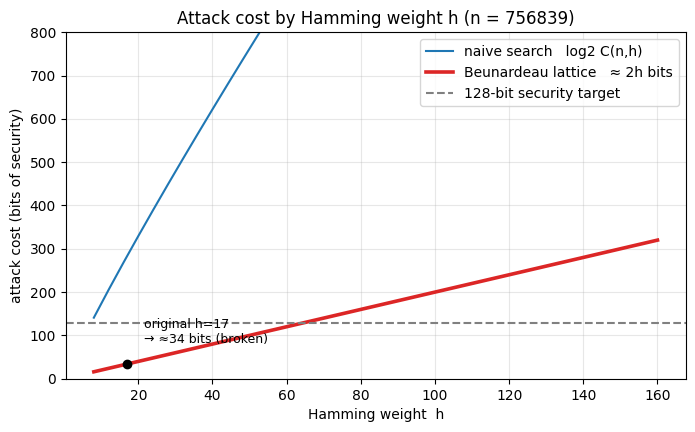

In [27]:
import math

n_vis = 756839
hs = list(range(8, 161, 4))

brute   = [math.log2(math.comb(n_vis, h)) for h in hs]
lattice = [2 * h for h in hs]

plt.figure()
plt.plot(hs, brute,   label="naive search   log2 C(n,h)")
plt.plot(hs, lattice, label="Beunardeau lattice   ≈ 2h bits", linewidth=2.6, color="#dc2626")
plt.axhline(128, color="gray", linestyle="--", label="128-bit security target")
plt.scatter([17], [34], color="black", zorder=5)
plt.annotate("original h=17\n→ ≈34 bits (broken)", (17, 0),
             textcoords="offset points", xytext=(12, 26), fontsize=9)
plt.xlabel("Hamming weight  h")
plt.ylabel("attack cost (bits of security)")
plt.title(f"Attack cost by Hamming weight h (n = {n_vis})")
plt.ylim(0, 800)
plt.legend()
plt.show()

## 10. The blockwise scheme (AJPS-2)

AJPS-1 spends a whole $n$-bit ciphertext on a *single* bit, so a $k$-bit message costs $k\cdot n$ bits. The blockwise scheme (AJPS-2) packs the entire message into two numbers ($2n$ bits total) no matter how long it is using the Combination problem and an error-correcting code $\mathcal{E}/\mathcal{D}$.

**Keys:** Public $(R,\,T)$ with $T = F\cdot R + G \bmod p$; secret key $F$.

**Encryption:** $m \in \{0,1\}^k$ with sparse $A, B_1, B_2$:
$$C_1 = A\cdot R + B_1, \qquad C_2 = (A\cdot T + B_2)\ \oplus\ \mathcal{E}(m) \pmod p.$$

**Decryption:** Return $\mathcal{D}\big(C_2 \oplus (F\cdot C_1 \bmod p)\big)$.

$F\cdot C_1$ rebuilds the mask $A\cdot T + B_2$ up to a *sparse* error, so $C_2 \oplus (F\cdot C_1)$ is the codeword $\mathcal{E}(m)$ with
only a few bits flipped, which $\mathcal{D}$ repairs.

The ciphertext is always two numbers, regardless of message length, so the bit blow-up of AJPS-1 disappears.

In [28]:
def rep_encode(m_bits, rep):
    cw, ones = 0, (1 << rep) - 1
    for i, bit in enumerate(m_bits):
        if bit:
            cw |= ones << (i * rep)
    return cw

def rep_decode(cw, k, rep):
    mask = (1 << rep) - 1
    return [1 if bin((cw >> i * rep) & mask).count("1") * 2 > rep else 0 for i in range(k)]


class AJPSBlockwise:
    def __init__(self, n, h, k, rng=None):
        self.n, self.h, self.k, self.p, self.rng = n, h, k, mersenne_prime(n), rng
        self.rep = n // k

    def keygen(self):
        R = self.rng.randrange(self.p) if self.rng else secrets.randbelow(self.p)
        F = sample_low_weight(self.n, self.h, self.rng)
        G = sample_low_weight(self.n, self.h, self.rng)
        return (R, (F * R + G) % self.p), F

    def encrypt(self, pk, m_bits):
        R, T = pk
        A  = sample_low_weight(self.n, self.h, self.rng)
        B1 = sample_low_weight(self.n, self.h, self.rng)
        B2 = sample_low_weight(self.n, self.h, self.rng)
        C1 = (A * R + B1) % self.p
        C2 = ((A * T + B2) % self.p) ^ rep_encode(m_bits, self.rep)
        return C1, C2

    def decrypt(self, F, ct):
        C1, C2 = ct
        return rep_decode(C2 ^ ((F * C1) % self.p), self.k, self.rep)

In [34]:
def to_bits(s):  return [(b >> i) & 1 for b in s for i in range(7, -1, -1)]
def to_bytes(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        v = 0
        for bit in bits[i:i + 8]:
            v = (v << 1) | bit
        out.append(v)
    return bytes(out)

message = "Blockwise makes it faster and smaller"
n, h, k = 216091, 128, len(message) * 8
bw = AJPSBlockwise(n, h, k, rng=random.Random(0))
pk, F = bw.keygen()
recovered = to_bytes(bw.decrypt(F, bw.encrypt(pk, to_bits(message.encode())))).decode(errors="replace")

print(f"message   : {message!r}  ({k} bits)")
print(f"recovered : {recovered!r}   match: {recovered == message}\n")
print(f"ciphertext size at this secure n = {n}:")
print(f"  AJPS-1 (one ciphertext per bit): {k} x {n} bits = {k*n//8//1024:>6} KB")
print(f"  blockwise (two numbers)        :   2 x {n} bits = {2*n//8//1024:>6} KB")
print(f"  -> blockwise stays at two numbers no matter how long the message is.")

message   : 'Blockwise makes it faster and smaller'  (296 bits)
recovered : 'Blockwise makes it faster and smaller'   match: True

ciphertext size at this secure n = 216091:
  AJPS-1 (one ciphertext per bit): 296 x 216091 bits =   7807 KB
  blockwise (two numbers)        :   2 x 216091 bits =     52 KB
  -> blockwise stays at two numbers no matter how long the message is.


## 11. Performance

Every operation is dominated by modular multiplication of $n$-bit numbers. Because security forces $n$ into the hundreds of thousands of bits, those multiplications become expensive. The table below shows how a single operation scales with $n$, followed by the payoff of the blockwise scheme for a realistic $128$-bit payload.

In [30]:
import time

def bench(fn, iters):
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    return (time.perf_counter() - t0) / iters * 1000

print(f"{'n':>8} {'keygen':>13} {'encrypt':>12} {'decrypt':>12}")
for n in (1279, 9689, 86243, 132049, 216091):
    c = AJPS(n, h=8)
    H, G = c.keygen()
    C = c.encrypt(H, 1)
    it = 30 if n < 5000 else (3 if n < 150000 else 1)
    kt = bench(lambda: c.keygen(),     it)
    et = bench(lambda: c.encrypt(H, 1), max(it, 3))
    dt = bench(lambda: c.decrypt(G, C), max(it, 3))
    print(f"{n:>8} {kt:>10.2f} ms {et:>9.2f} ms {dt:>9.2f} ms")

       n        keygen      encrypt      decrypt
    1279       0.29 ms      0.05 ms      0.01 ms
    9689       7.89 ms      0.42 ms      0.27 ms
   86243     469.89 ms     21.65 ms     24.07 ms
  132049    1080.23 ms     30.95 ms     34.83 ms
  216091    2667.88 ms     93.63 ms     83.60 ms


In [32]:
n, bits = 216091, 128

a = AJPS(n, h=8)
H, G = a.keygen()
t0 = time.perf_counter()
cts = [a.encrypt(H, 1) for _ in range(bits)]
_   = [a.decrypt(G, c) for c in cts]
t_bitbybit = (time.perf_counter() - t0) * 1000

bw = AJPSBlockwise(n, h=8, k=bits)
pk, F = bw.keygen()
m = [1] * bits
t0 = time.perf_counter()
ct = bw.encrypt(pk, m)
_  = bw.decrypt(F, ct)
t_block = (time.perf_counter() - t0) * 1000

print(f"sending a {bits}-bit key at n = {n}:")
print(f"  AJPS-1 (bit-by-bit): {t_bitbybit:8.1f} ms   ({bits} ciphertexts, ~{bits*n//8//1024} KB)")
print(f"  blockwise          : {t_block:8.1f} ms   (2 numbers, ~{2*n//8} bytes)")

sending a 128-bit key at n = 216091:
  AJPS-1 (bit-by-bit):  26299.8 ms   (128 ciphertexts, ~3376 KB)
  blockwise          :    272.3 ms   (2 numbers, ~54022 bytes)


## References

1. D. Aggarwal, A. Joux, A. Prakash, M. Santha. *A New Public-Key Cryptosystem via Mersenne
   Numbers.* CRYPTO 2018, LNCS 10993, 459&ndash;482.
2. M. Beunardeau, A. Connolly, R. Géraud, D. Naccache. *On the Hardness of the Mersenne Low
   Hamming Ratio Assumption.* IACR ePrint 2017/522.
3. J.-S. Coron, A. Gini. *Improved Cryptanalysis of the AJPS Mersenne Based Cryptosystem.*
   IACR ePrint 2019/610; J. Mathematical Cryptology, 2020.